In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sys
import os
from importlib import reload
import re
import time
current_dir = os.path.abspath('')
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

import util
import util_working
from jax import numpy as jnp

# Plot-Formatierung
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0

In [3]:
''' Parameter for the model '''
rho_dm = 0.025
rhos = jnp.array([0.021, 0.016, 0.012, 0.0009, 0.0006, 0.0031, 0.0015, 0.0020, 0.0022, 0.007, 0.0135, 0.006, 0.002, 0.0035, 0.0001])
sigmas = jnp.array([4., 7., 9., 40., 20., 7.5, 10.5, 14., 18., 18.5, 18.5, 20., 20., 37., 100.])
erhos = jnp.array([0.5, 0.5, 0.5, 0.5, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2]) * rhos
esigmas = jnp.array([1., 1., 1., 1., 2., 2., 2., 2., 2., 2., 2., 5., 5., 5., 10.])
params = jnp.transpose(jnp.vstack((rhos, sigmas)))

In [4]:
def bounds(mean, std):
    mu = jnp.log(mean)-0.5*jnp.log((std/mean)**2+1)
    sigma = jnp.sqrt(jnp.log((std/mean)**2+1))
    mu_ = jnp.exp(mu)
    sigma_ = jnp.exp(sigma)
    return mu_/sigma_, mu_*sigma_

def extract_values(s):
    z2_match = re.search(r'z2:(\d+\.?\d*)', s)
    z1_match = re.search(r'z1:(\d+\.?\d*)', s)
    pn_match = re.search(r'data:(\w+)', s)
    name_match = re.search(r'n:(\w+)', s)
    
    z2_value = float(z2_match.group(1)) if z2_match else None
    z1_value = float(z1_match.group(1)) if z1_match else None
    pn_value = pn_match.group(1) if pn_match else None
    name_value = name_match.group(1) if name_match else None
    
    return z2_value, z1_value, pn_value, name_value

def find_row_index(file_path, z2_target, z1_target, pn_target, name_target):
    with open('results/'+file_path, 'r') as file:
        for i, line in enumerate(file):
            z2_value, z1_value, pn_value, name_value = extract_values(line)
            if z2_value == z2_target and z1_value == z1_target and pn_value == pn_target and name_value == name_target:
                index = i
                break
    
    return index

def read_res(file_rho, file_rd, file_sigma, file_sd, file_cf, file_dfo):
    rho = jnp.array(pd.read_csv('results/'+file_rho, header=None).iloc[:,1])
    erho = jnp.array(pd.read_csv('results/'+file_rho, header=None).iloc[:,2])
    rd = jnp.array(pd.read_csv('results/'+file_rd, header=None).iloc[:,1])
    erd = jnp.array(pd.read_csv('results/'+file_rd, header=None).iloc[:,2])
    sigma = jnp.array(pd.read_csv('results/'+file_sigma, header=None).iloc[:,1])
    esigma = jnp.array(pd.read_csv('results/'+file_sigma, header=None).iloc[:,2])
    sd = jnp.array(pd.read_csv('results/'+file_sd, header=None).iloc[:,1])
    esd = jnp.array(pd.read_csv('results/'+file_sd, header=None).iloc[:,2])
    param = jnp.column_stack((rho, sigma))
    cf = pd.read_csv('results/'+file_cf, header=None).iloc[:,3]
    e_cf = pd.read_csv('results/'+file_cf, header=None).iloc[:,4]
    dfo = pd.read_csv('results/'+file_dfo, header=None).iloc[:,3]
    e_dfo = pd.read_csv('results/'+file_dfo, header=None).iloc[:,4]
    return rho, erho, rd, erd, sigma, esigma, sd, esd, param, cf, e_cf, dfo, e_dfo

def read_samples(file_rho, file_rd, file_sigma, file_sd, file_cf):
    rhos = np.array(pd.read_csv('results/'+file_rho, header=None).iloc[:,3])
    rds = np.array(pd.read_csv('results/'+file_rd, header=None).iloc[:,3])
    sigmas = np.array(pd.read_csv('results/'+file_sigma, header=None).iloc[:,3])
    sds = np.array(pd.read_csv('results/'+file_sd, header=None).iloc[:,3])
    return rhos, rds, sigmas, sds

colors = ['green','orange','purple','cyan','magenta','teal','darkblue','darkgreen','darkred','brown','navy','indigo']

In [5]:
def plot_params(subsample, include, title=None, re=None):
    ''' Parameter for the model '''
    if re != None:
        rho, erho, rd, erd, sigma, esigma, sd, esd, param, _, _, _, _ = read_res(f'rho_bin_{subsample}{re}.csv', f'rd_bin_{subsample}{re}.csv', f'sigma_bin_{subsample}{re}.csv', f'sd_bin_{subsample}{re}.csv', f'cf_bin_{subsample}{re}.csv', f'dfo_bin_{subsample}{re}.csv')
    else:
        rho, erho, rd, erd, sigma, esigma, sd, esd, param, _, _, _, _ = read_res(f'rho_bin_{subsample}.csv', f'rd_bin_{subsample}.csv', f'sigma_bin_{subsample}.csv', f'sd_bin_{subsample}.csv', f'cf_bin_{subsample}.csv', f'dfo_bin_{subsample}.csv')

    ''' Visualisation '''
    fig, ax = plt.subplots(1, 2, figsize=(20, 10))
    ax[0].set_title(title)
    plt.title(f'[{subsample}]')

    j = 0
    for set in include:
        if re != None:
            i = find_row_index(f'rd_bin_{subsample}{re}.csv', set[0], set[1], set[2], set[3])
        else:
            i = find_row_index(f'rd_bin_{subsample}.csv', set[0], set[1], set[2], set[3])
        ax[0].errorbar(rhos+j*0.00012, rho[i*15:(i+1)*15], yerr=erho[i*15:(i+1)*15], fmt='o', alpha=0.7, color = colors[j])
        ax[1].errorbar(sigmas+j*0.6, sigma[i*15:(i+1)*15], yerr=esigma[i*15:(i+1)*15], fmt='o', label=f'[{set[0]:.0f}, {set[1]:.0f}]pc, {set[2]} {set[4]}', alpha=0.7, color = colors[j])
        plt.figtext(0.15, 0.84-j*0.04, f'$\Sigma$ = ({sd[i]:.3f} +/- {esd[i]:.3f}) M_sun/pc^2', fontsize=18, color = colors[j])
        
        j += 1

    ax[0].plot([0, 0.022], [0, 0.022], color='black', linestyle='--')
    rho_sorted = np.argsort(rhos)
    ax[0].fill_between(rhos[rho_sorted], (rhos+erhos)[rho_sorted], y2=(rhos-erhos)[rho_sorted], alpha=0.1, color='gray', label='gauß 0.683')
    ax[0].fill_between(rhos[rho_sorted], bounds(rhos[rho_sorted], erhos[rho_sorted])[0], y2=bounds(rhos[rho_sorted], erhos[rho_sorted])[1], alpha=0.1, color='blue', label='lognormal 0.683')
    ax[0].set_xlabel(r"True $\rho$")
    ax[0].set_ylabel(r"Inferred $\rho$")
    ax[0].grid()
    ax[0].legend(fontsize='16')

    ax[1].plot([0, 110], [0, 110], color='black', linestyle='--')
    sigma_sorted = np.argsort(sigmas)
    ax[1].fill_between(sigmas[sigma_sorted], (sigmas+esigmas)[sigma_sorted], y2=(sigmas-esigmas)[sigma_sorted], alpha=0.1, color='gray')
    ax[1].fill_between(sigmas[sigma_sorted], bounds(sigmas[sigma_sorted], esigmas[sigma_sorted])[0], y2=bounds(sigmas[sigma_sorted], esigmas[sigma_sorted])[1], alpha=0.1, color='blue')
    ax[1].set_xlabel("True $\sigma$")
    ax[1].set_ylabel("Inferred $\sigma$")
    ax[1].grid()
    ax[1].legend(fontsize='16')
    plt.savefig(f'results/{subsample}_{title}_params.png')
    fig.set_dpi(30)
    plt.show()

In [6]:
reload(util)
reload(util_working)

def plot_fits(subsample, include, title=None, re=None):
    ''' real data '''
    n_real = np.loadtxt(f'data/n_{subsample}.txt')
    n_std = np.loadtxt(f'data/n_std_{subsample}.txt')
    bins = np.loadtxt(f'data/bins_{subsample}.txt')
    zz_real = (bins[1:]+bins[:-1])/2
    pos = np.where(zz_real >= 0)
    neg = np.where(zz_real < 0)

    data_v2 = pd.read_csv(f'data/v2_bin_{subsample}.txt')
    z_v2 = np.array(data_v2.iloc[:,0])
    v2 = np.array(data_v2.iloc[:,2])
    e_v2 = np.array(data_v2.iloc[:,4])
    pos_v2 = np.where(z_v2 >= 0)
    neg_v2 = np.where(z_v2 < 0)

    ''' Domain '''
    z2 = 0.
    z1 = max(bins)
    poly = np.loadtxt(f'data/poly_{subsample}.txt')
    i2 = np.where(bins<=z2)[0][-1]
    i1 = np.where(bins>=z1)[0][0]
    z2 = bins[i2]
    z1 = bins[i1]
    n = int(z1)+1
    n_bins = int(len(bins[i2:i1+1])-1)

    ''' Parameter for the model '''
    if re != None:
        rho, erho, rd, erd, sigma, esigma, sd, esd, param, cf, e_cf, dfo, e_dfo = read_res(f'rho_bin_{subsample}{re}.csv', f'rd_bin_{subsample}{re}.csv', f'sigma_bin_{subsample}{re}.csv', f'sd_bin_{subsample}{re}.csv', f'cf_bin_{subsample}{re}.csv', f'dfo_bin_{subsample}{re}.csv')
    else:
        rho, erho, rd, erd, sigma, esigma, sd, esd, param, cf, e_cf, dfo, e_dfo = read_res(f'rho_bin_{subsample}.csv', f'rd_bin_{subsample}.csv', f'sigma_bin_{subsample}.csv', f'sd_bin_{subsample}.csv', f'cf_bin_{subsample}.csv', f'dfo_bin_{subsample}.csv')

    ''' Visualisation '''
    fig, ax = plt.subplots(2,1, figsize=(20,20), sharex=True)
    ax[0].set_title(title)

    ax[0].errorbar(zz_real[pos], n_real[pos], yerr=np.sqrt(n_real[pos]), label=f"{subsample} pos", c='blue', fmt='x')
    ax[0].errorbar(np.abs(zz_real[neg]), n_real[neg], yerr=np.sqrt(n_real[neg]), label=f"{subsample} neg", c='red', fmt='x')


    ax[0].set_yscale("log")
    ax[1].set_xlabel("Height z above/below galactic mid-plane in pc")
    ax[0].set_ylabel("#K-type stars")
    ax[1].set_ylabel("$\sigma_z^2$ in $(kms^{-1})^2$")

    ax[1].plot(zz_real[pos], poly[0]*zz_real[pos]+poly[1], ls='-', label=f"{subsample} fit", linewidth=2, c='black')
    ax[1].errorbar(z_v2[pos_v2], v2[pos_v2], yerr=e_v2[pos_v2], fmt='.', label=f"{subsample} v2 pos", c='blue')
    ax[1].errorbar(np.abs(z_v2[neg_v2]), v2[neg_v2], yerr=e_v2[neg_v2], fmt='.', label=f"{subsample} v2 neg", c='red')
    
    j=0
    for set in include:
        i2_ = np.where(bins == set[0])[0][0] - len(bins)//2
        i1_ = np.where(bins == set[1])[0][0] - len(bins)//2
        if re != None:
            i = find_row_index(f'rd_bin_{subsample}{re}.csv', set[0], set[1], set[2], set[3])
        else:
            i = find_row_index(f'rd_bin_{subsample}.csv', set[0], set[1], set[2], set[3])
        cf_i = jnp.array([float(el) for el in cf[i].strip('[]').split()])
        ecf_i = jnp.array([float(el) for el in e_cf[i].strip('[]').split()])
        dfo_i = jnp.array([float(el) for el in dfo[i].strip('[]').split()])
        e_dfo_i = jnp.array([float(el) for el in e_dfo[i].strip('[]').split()])
    
        ''' calculated data'''
        uz, zs = util_working.diffraxDopri5(rd[i], param[i*15:(i+1)*15], z1, n)

        vdfo_norm_calc, z, _ = util_working.vdfo_norm(z2, z1, zs, uz, n, poly, cf_i, np.array([0]))
        integral, z_borders = util_working.binning(vdfo_norm_calc, z, z2, z1, n, n_bins)
        norm = np.sum(n_real[pos][i2_:i1_]) if set[2] == 'pos' else np.sum(np.flip(n_real[neg])[i2_:i1_])
        n_ = integral / sum(integral[i2_:i1_]) * norm
        zz = (z_borders[1:] + z_borders[:-1]) / 2

        ax[0].plot(zz, n_, label=f'[{set[0]:.0f}, {set[1]:.0f}]pc, {set[2]} {set[4]}', color=colors[j])
        if set[2] == 'pos':
            ax[0].fill_between(zz, n_-n_std[pos], n_+n_std[pos], alpha=0.1, color=colors[j])
        elif set[2] == 'neg':
            ax[0].fill_between(zz, n_-np.flip(n_std[neg]), n_+np.flip(n_std[neg]), alpha=0.1, color=colors[j])
        # ax[0].errorbar(zz[i2_:i1_], dfo_i, yerr=e_dfo_i, fmt='.', color=colors[j], alpha=0.9)
        
        #data + poisson uncertainty
        #inferred+inference uncertainty
        #model+parallax uncertainty
        
        plt.figtext(0.15, 0.65-j*0.02, f'rho_dm = ({rd[i]:.4f} +/- {erd[i]:.4f}) M_sun/pc^3', color=colors[j], fontsize=18)

        grid = jnp.linspace(0, set[1], int(set[1])+1)
        ax[1].plot(grid, cf_i, label=f'[{set[0]:.0f}, {set[1]:.0f}]pc, {set[2]} {set[4]}', color=colors[j])
        ax[1].fill_between(grid, cf_i+ecf_i, cf_i-ecf_i, alpha=0.1, color=colors[j])

        #ax[1].plot(grid, (10./1200.*grid+17.)**2, label='read')

        j+=1
    ax[0].legend(fontsize='18')
    ax[0].grid(which='both')
    ax[1].legend(fontsize='18')
    ax[1].grid(which='both')
    ax[0].set_ylim(5e+1, 3e+4)
    plt.tight_layout()
    fig.subplots_adjust(hspace=0)
    plt.savefig(f'results/{subsample}_{title}_fit.png')
    fig.set_dpi(30)
    plt.show()

In [7]:
reload(util)
reload(util_working)

def plot_correl(subsample, include, title=None, re=None):

    ''' Samples for the model '''
    if re != None:
        rhos, rds, sigmas, sds = read_samples(f'rho_bin_{subsample}{re}.csv', f'rd_bin_{subsample}{re}.csv', f'sigma_bin_{subsample}{re}.csv', f'sd_bin_{subsample}{re}.csv', f'cf_bin_{subsample}{re}.csv')
        rho, erho, rd, erd, sigma, esigma, sd, esd, param, _, _, _, _ = read_res(f'rho_bin_{subsample}{re}.csv', f'rd_bin_{subsample}{re}.csv', f'sigma_bin_{subsample}{re}.csv', f'sd_bin_{subsample}{re}.csv', f'cf_bin_{subsample}{re}.csv', f'dfo_bin_{subsample}{re}.csv')
    else:
        rhos, rds, sigmas, sds = read_samples(f'rho_bin_{subsample}.csv', f'rd_bin_{subsample}.csv', f'sigma_bin_{subsample}.csv', f'sd_bin_{subsample}.csv', f'cf_bin_{subsample}.csv')
        rho, erho, rd, erd, sigma, esigma, sd, esd, param, _, _, _, _ = read_res(f'rho_bin_{subsample}.csv', f'rd_bin_{subsample}.csv', f'sigma_bin_{subsample}.csv', f'sd_bin_{subsample}.csv', f'cf_bin_{subsample}.csv', f'dfo_bin_{subsample}.csv')


    ''' Visualisation '''
    fig, ax = plt.subplots(1,2, figsize=(20, 10))
    # ax = [ax]
    ax[0].set_title(title)
    plt.title(f'[{subsample}]')

    j = 0
    for set in include:
        if re != None:
            i = find_row_index(f'rd_bin_{subsample}{re}.csv', set[0], set[1], set[2], set[3])
        else:
            i = find_row_index(f'rd_bin_{subsample}.csv', set[0], set[1], set[2], set[3])
        rho_11 = rhos[i*15+10]
        rho_11 = rho_11.strip('()').split(', ')
        rho_11 = np.array([float(item) for item in rho_11])
        sigma_11 = sigmas[i*15+10]
        sigma_11 = sigma_11.strip('()').split(', ')
        sigma_11 = np.array([float(item) for item in sigma_11])
        rho_s = jnp.zeros(rho_11.shape)
        for k in range(15):
            rho_k = rhos[i*15+k]
            rho_k = rho_k.strip('()').split(', ')
            rho_k = np.array([float(item) for item in rho_k])
            rho_s = rho_s+rho_k
        rd = rds[i]
        rd = rd.strip('()').split(', ')
        rd = np.array([float(item) for item in rd])
        sd = sds[i]
        sd = sd.strip('()').split(', ')
        sd = np.array([float(item) for item in sd])
        ax[0].scatter(rho_s, rd, marker='x', alpha=0.7, color = colors[j])
        # ax[1].scatter(rho_11, sigma_11, marker='x', label=f'[{set[0]:.0f}, {set[1]:.0f}]pc, {set[2]}, {set[3]}', alpha=0.7, color = colors[j])
        ax[1].scatter(sd, rd, marker='x', label=f'[{set[0]:.0f}, {set[1]:.0f}]pc, {set[2]}, {set[4]}', alpha=0.7, color = colors[j])
        # plt.figtext(0.15, 0.84-j*0.04, f'$\Sigma$ = ({sd[i]:.3f} +/- {esd[i]:.3f}) M_sun/pc^2', fontsize=18, color = colors[j])
        
        j += 1

    ax[0].set_xlabel(rf"$\rho_s/M_{{\odot}}pc^{-3}$")
    ax[0].set_ylabel(rf"$\rho_{{dm}}/M_{{\odot}}pc^{-3}$")
    ax[0].set_ylim(0.005,0.025)
    ax[0].set_xlim(0.025,0.15)
    ax[0].grid()
    ax[0].legend(fontsize='16')

    # ax[1].set_xlabel(rf"$\rho_1/M_{{\odot}}pc^{-3}$")
    # ax[1].set_ylabel(rf"$\sigma_1/kms^{-1}$")
    # ax[1].set_xlim(0.014-0.008, 0.014+0.008)
    # ax[1].set_ylim(19-10, 19+10)
    ax[1].set_xlabel(rf"$\Sigma/M_{{\odot}}pc^{-2}$")
    ax[1].set_ylabel(rf"$\rho_{{dm}}/M_{{\odot}}pc^{-3}$")
    ax[1].set_xlim(34.4, 64.4)
    ax[1].set_ylim(0.005,0.025)
    ax[1].grid()
    ax[1].legend(fontsize='16')
    plt.tight_layout()
    plt.savefig(f'results/{subsample}_{title}_correl.png')
    fig.set_dpi(30)
    plt.show()

In [8]:
def complete(subsample, include, title=None, re=None):
    plot_params(subsample, include, title, re=re)
    plot_fits(subsample, include, title, re=re)
    plot_correl(subsample, include, title, re=re)

In [9]:
# complete('full_o1m4', [[108, 864, 'pos', 'withunc'], [108, 864, 'pos', 'withuncit30'], [108, 864, 'pos', 'withuncit45'], [108, 864, 'pos', 'withuncit45otherargs'], [108, 864, 'pos', 'withuncit60'], [108, 1152, 'pos', 'withunc'], [108, 1476, 'pos', 'withunc'],[108, 1476, 'pos', 'withuncit60']], title='test uncertainty freedom')

In [10]:

# complete('full_o1m4', [[108, 864, 'pos', 'withoutunc'], [108, 864, 'pos', 'withuncoutit60'], [108, 1152, 'pos', 'withoutunc'], [108, 1152, 'pos', 'withuncoutit60'], [108, 1476, 'pos', 'withoutunc']], title='test  nouncertainty freedom')

In [11]:
# complete('full_o1m4', [[180, 828, 'pos', 'it10samp10'], [180, 828, 'pos', 'it20samp10'], [180, 828, 'pos', 'it30samp10'], [180, 828, 'pos', 'it40samp10'], [180, 828, 'pos', 'it50samp10'], [180, 828, 'pos', 'it60samp10'], [180, 828, 'pos', 'it100samp10']], title='test iteration (small interval upper)')

In [12]:
# complete('full_o1m4', [[180, 828, 'pos', 'it30samp10'], [180, 828, 'pos', 'it30samp15'], [180, 828, 'pos', 'it30samp20'], [180, 828, 'pos', 'it30samp25']], title='test samples (small interval upper)')

In [13]:
# complete('full_o1m4', [[180, 828, 'pos', 'it1samp10smooth'], [180, 828, 'pos', 'it10samp15smooth'], [180, 828, 'pos', 'it20samp15smooth'], [180, 828, 'pos', 'it30samp15smooth'], [180, 828, 'pos', 'it40samp15smooth'], [180, 828, 'pos', 'it50samp15smooth'], [180, 828, 'pos', 'it100samp15smooth']], title='test iteration smooth (small interval upper)')

In [14]:
# complete('full_o1m4', [[180, 828, 'pos', 'it1samp25smooth'], [180, 828, 'pos', 'it2samp25smooth'], [180, 828, 'pos', 'it10samp25smooth'], [180, 828, 'pos', 'it30samp25smooth'], [180, 828, 'pos', 'it50samp25smooth'], [180, 828, 'pos', 'it100samp25smooth']], title='test iteration smooth more samples (small interval upper)')

In [15]:
# complete('upper_o1m4', [[180, 1008, 'pos', 'final'], [180, 1008, 'pos', 'finalit20'], [180, 1224, 'pos', 'final'], [108, 1224, 'pos', 'final'], [180, 1404, 'pos', 'final'], [180, 1404, 'pos', 'finalit20'], [180, 1404, 'pos', 'finalit30']], title='first run pos upper')

In [16]:
# complete('upper_o1m4', [[180, 1008, 'neg', 'final'], [180, 1224, 'neg', 'final'], [180, 1404, 'neg', 'final']], title='first run neg upper') 

In [17]:
# complete('upper_o1m4', [[180, 1404, 'pos', 'finalit5'], [180, 1404, 'pos', 'final'], [180, 1404, 'pos', 'finalit20'], [180, 1404, 'pos', 'finalit30'], [180, 1404, 'pos', 'finalit50']], title='test iteration (large interval upper)')

In [18]:
# complete('upper_o1m4', [[180, 1404, 'pos', 'it5samp10'], [180, 1404, 'pos', 'it10samp10'], [180, 1404, 'pos', 'it30samp10'], [180, 1404, 'pos', 'it50samp10'], [180, 1404, 'pos', 'it100samp10']], title='test iteration (large interval upper)')

In [19]:
# complete('upper_o1m4', [[180, 1620, 'pos', 'it5samp10'], [180, 1620, 'pos', 'it10samp10'], [180, 1620, 'pos', 'it30samp10'], [180, 1620, 'pos', 'it50samp10']], title='test iteration (larger interval upper)')

In [20]:
# complete('full_o1m3', [[180, 1008, 'pos', 'final'], [180, 1224, 'pos', 'final'], [180, 1404, 'pos', 'final'], [180, 1620, 'pos', 'final'], [72, 1404, 'pos', 'final'], [288, 1404, 'pos', 'final']], title='o1m3 full test')

In [21]:
# complete('full_o1m4', [[180, 792, 'pos', 'last'], [180, 1188, 'pos', 'lastit20'], [180, 1188, 'pos', 'lastlast'], [180, 1188, 'pos', 'last'], [180, 1080, 'pos', 'last'], [180, 1188, 'neg', 'last'], [180, 1080, 'neg', 'last']], title='o1m4 full test')

In [22]:
# complete('full_o1m4', [[180, 1188, 'pos', 'f42'], [180, 1188, 'pos', 'f80'], [180, 1188, 'pos', 'f440'] , [180, 1188, 'pos', 'f42it100'], [180, 1188, 'pos', 'f80it100'], [180, 1188, 'pos', 'f42it200sa10'], [180, 1188, 'pos', 'f42it30sa30'], [180, 1188, 'pos', 'f689'], [180, 1188, 'pos', 'f10'], [180, 1188, 'pos', 'f10it100']], title='o1m4 full test')

### Finale Tests

In [23]:
# complete('upper_o1m4', [[180, 1008, 'pos', 'last', ''], [180, 1188, 'pos', 'last', ''], [180, 1224, 'pos', 'f80', ''], [180, 1404, 'pos', 'f80', ''], [180, 1620, 'pos', 'last', '']], title='upper pos') #upper o1m4 pos
# #[108, 1224, 'pos', 'last'], [216, 1224, 'pos', 'last'], [216, 1404, 'pos', 'last'], [180, 1404, 'pos', 'last'], [180, 1224, 'pos', 'last']

In [24]:
# complete('upper_o1m4', [[180, 1008, 'neg', 'last', ''], [180, 1224, 'neg', 'last', ''],  [180, 1404, 'neg', 'last', ''], [180, 1620, 'neg', 'f80', ''], ], title='upper neg') #upper o1m4 neg
# # [108, 1224, 'neg', 'last'], [180, 1620, 'neg', 'last']

In [25]:
# complete('lower_o1m4', [[180, 972, 'neg', 'last', ''], [180, 1008, 'neg', 'f10', ''], [180, 1152, 'neg', 'last', ''], [180, 1188, 'neg', 'last', '']], title='lower neg') #lower o1m4 neg
# # [108, 756, 'neg', 'last'],[108, 756, 'neg', 'lastit50'], [108, 972, 'neg', 'last'], [108, 1152, 'neg', 'last'],

In [26]:
# complete('lower_o1m4', [[180, 972, 'pos', 'last', ''], [180, 1008, 'pos', 'f10', ''], [180, 1152, 'pos', 'f10', ''], [180, 1188, 'pos', 'last', '']], title='lower pos') # lower o1m4 pos
# #[108, 756, 'pos', 'last'], [108, 972, 'pos', 'last'], [108, 1152, 'pos', 'lastit50'], [180, 1008, 'pos', 'f80']

In [27]:
#  # complete('full_o1m4', [[180, 1188, 'pos', 'ff80'], [180, 1188, 'pos', 'ff689'], [180, 1188, 'neg', 'f80'], [180, 1188, 'neg', 'f689']], title='seed [o1m4]')

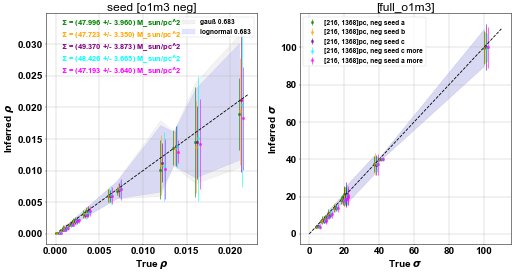

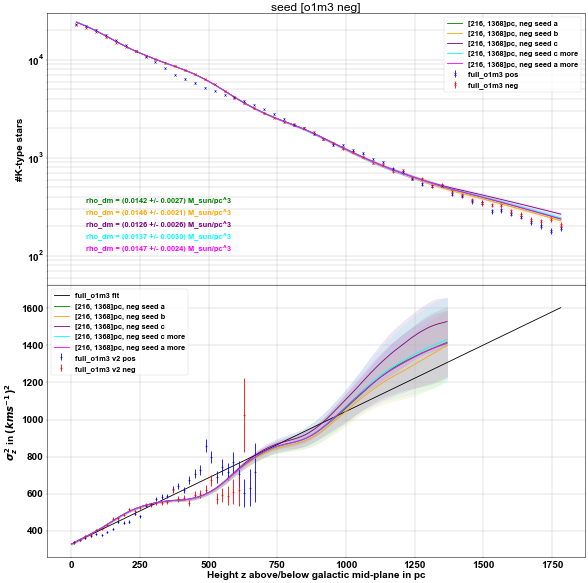

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


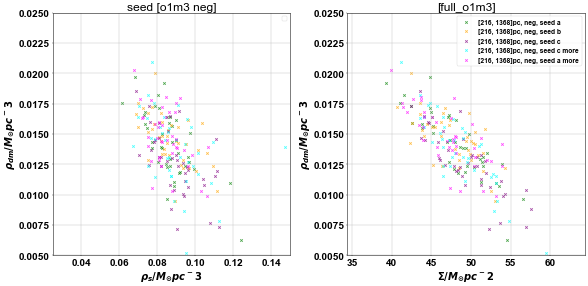

In [28]:
complete('full_o1m3', [[216, 1368, 'neg', 'f42it30', 'seed a'], [216, 1368, 'neg', 'f45it30', 'seed b'], [216, 1368, 'neg', 'f10it30', 'seed c'], [216, 1368, 'neg', 'f10it50', 'seed c more'], [216, 1368, 'neg', 'f42it50', 'seed a more']], title='seed [o1m3 neg]')

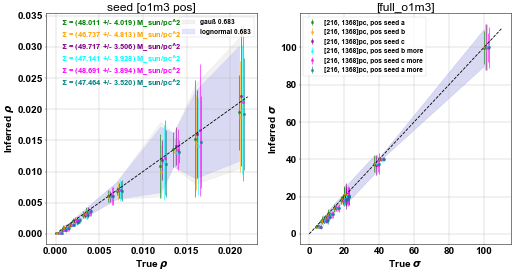

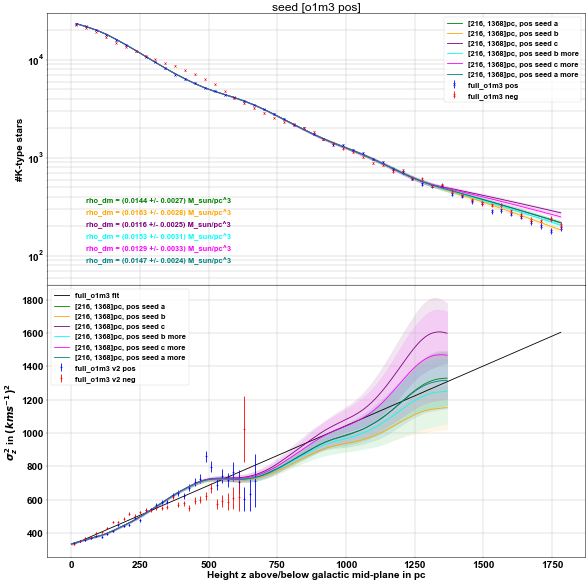

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


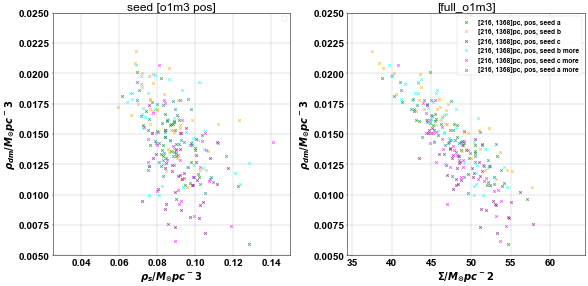

In [33]:
complete('full_o1m3', [[216, 1368, 'pos', 'f42it30', 'seed a'], [216, 1368, 'pos', 'f689it30', 'seed b'], [216, 1368, 'pos', 'f10it30', 'seed c'], [216, 1368, 'pos', 'f689it50', 'seed b more'], [216, 1368, 'pos', 'f10it50', 'seed c more'], [216, 1368, 'pos', 'f42it50', 'seed a more']], title='seed [o1m3 pos]') 

In [30]:
# complete('full_o1m4', [[180, 1188, 'pos', 'f42', 'seed a 50 iterations'], [180, 1188, 'pos', 'f42it100', 'seed a 100 iterations'], [180, 1188, 'pos', 'f10', 'seed c 50 iterations'], [180, 1188, 'pos', 'f10it100', 'seed c 100 iterations']], title='iteration [o1m4 pos]')

In [31]:
# complete('full_o1m4', [[180, 1188, 'neg', 'f42', 'seed a 50 iterations'], [180, 1188, 'neg', 'ff42it100', 'seed a 100 iterations'], [180, 1188, 'neg', 'f80', 'seed b 50 iterations'], [180, 1188, 'neg', 'ff80it100', 'seed b 100 iterations']], title='iteration [o1m4 neg]')

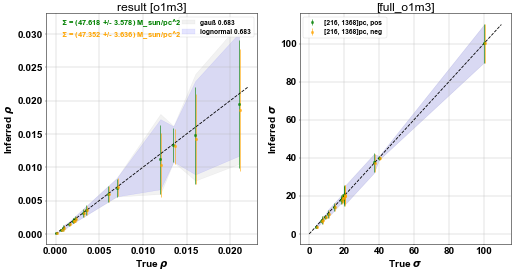

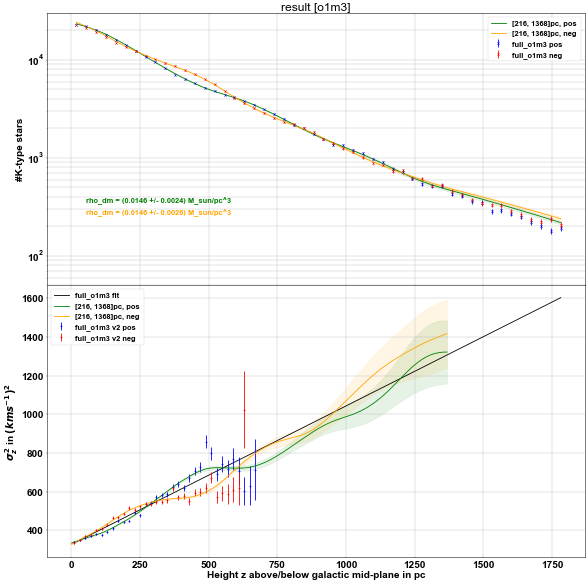

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


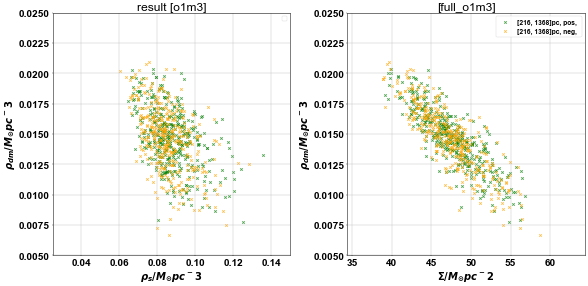

In [34]:
complete('full_o1m3', [[216, 1368, 'pos', 'f42it50', ''], [216, 1368, 'neg', 'f42it50', '']], title='result [o1m3]', re='re')